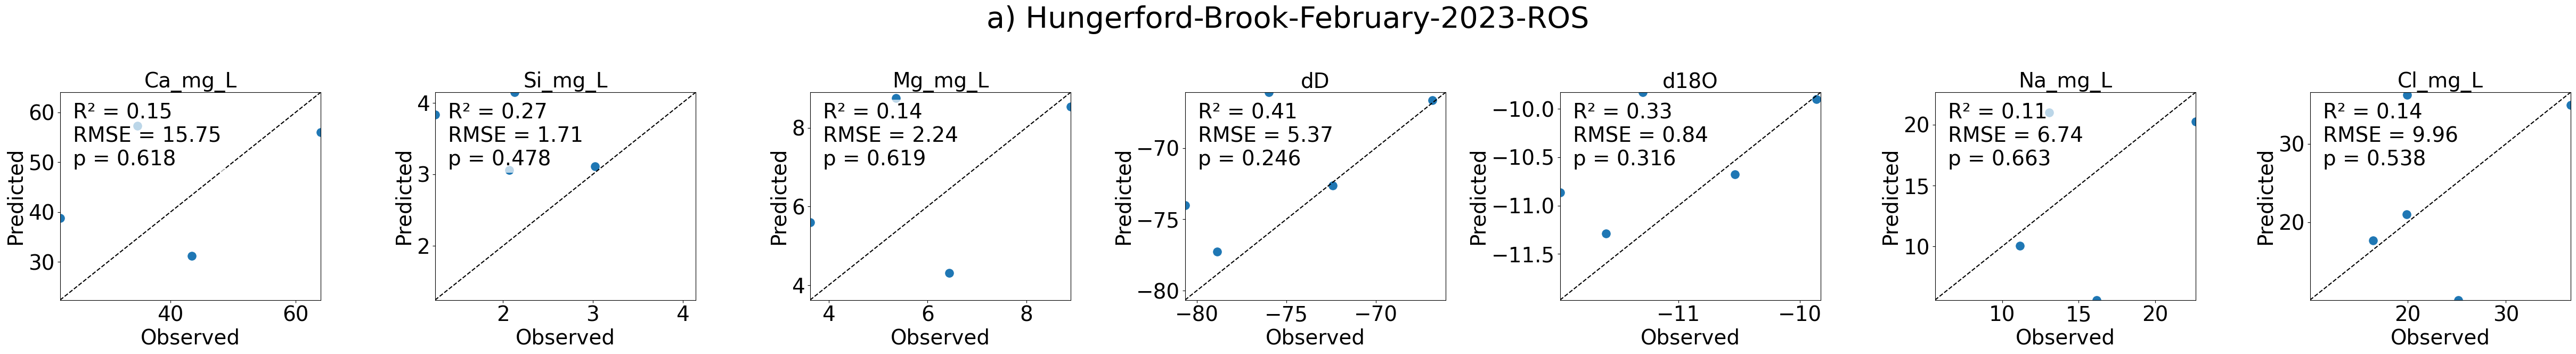

In [30]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data/GrabSample_data"

output_dir = repo_dir / "Output/EMMA-uncertainty/Tracer_regressions/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "RI23-IC-ICP-isotope-toc-joined.csv")

##########################
# Hungerford RI23 events #
##########################

hungerford_febros_fractions_df, hungerford_febros_scaler, hungerford_febros_pca, hungerford_febros_endmembers_df = em.run_emma_event(
    data=df,
    site="Hungerford",
    start_date="2023-02-08 00:00:00",
    end_date="2023-02-12 00:00:00",
    endmember_ids=[
                   "RI23-1001", # Baseflow 
                   "RI23-5003", # SWLD 02/15/2023
                   "RI23-5002"] # SML 02/15/2023
)

hungerford_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L', 'Cl_mg_L']

# Call the prediction function
hungerford_febros_predicted = em.predict_tracers_from_fractions(
    fractions_df=hungerford_febros_fractions_df,
    endmembers_df=hungerford_febros_endmembers_df,
    tracer_cols=hungerford_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title="a) Hungerford-Brook-February-2023-ROS", 
    predicted_df=hungerford_febros_predicted, 
    stream_df=df, 
    tracer_cols=hungerford_tracers, 
    output_dir=output_dir
)

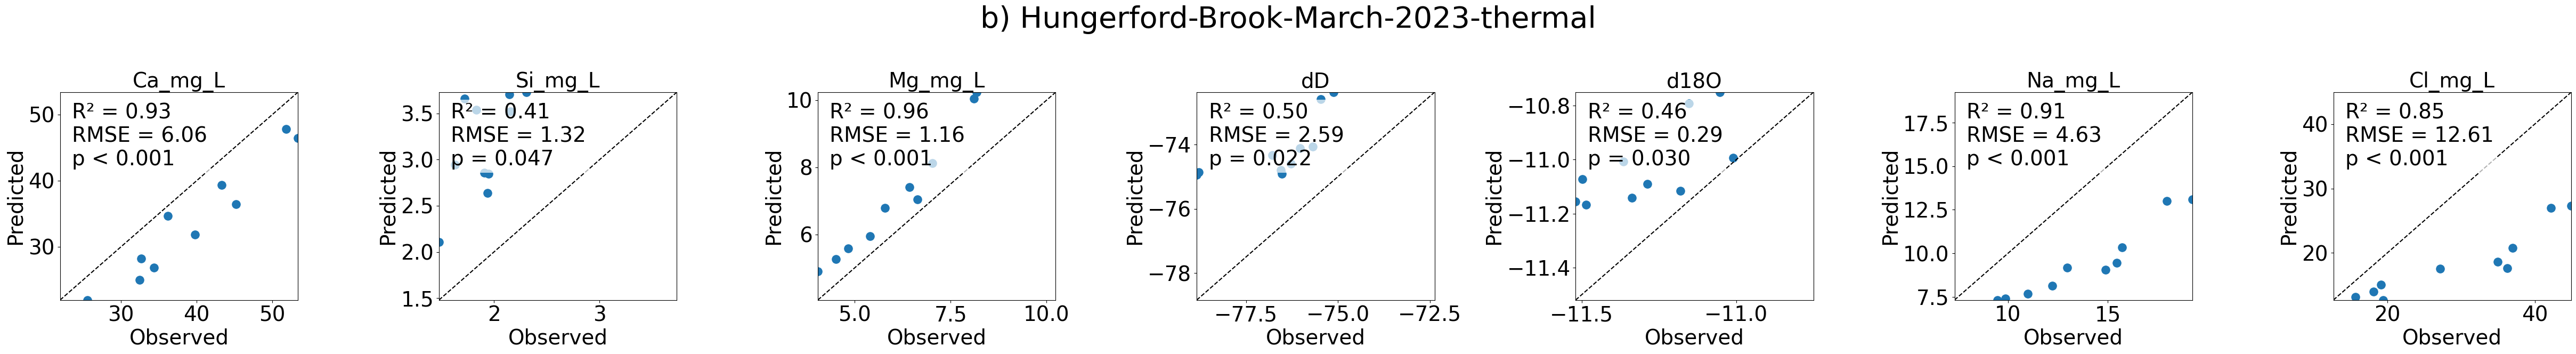

In [29]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data/GrabSample_data"

output_dir = repo_dir / "Output/EMMA-uncertainty/Tracer_regressions/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "RI23-IC-ICP-isotope-toc-joined.csv")

##########################
# Hungerford RI23 events #
##########################

# Event B
# Hungerford March thermal event
# Potential endmembers: 
    # RI23-5008 Groundwater (Mark's well) 03/16/2023
    # RI20-HB-DGW-Mark-1 Mark's well 06/23/2020
    # RI22-0858 03/17/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI22-0864 07/27/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI23-1035 Baseflow 03/31/2023
    # RI23-1001 # Baseflow 02/09/2023 (labeled GW)
    # RI23-5007 Soil water lysimeter dry 03/16/2023
    # RI23-1061 Snowmelt lysimeter 03/28/2023

hungerford_martherm_fractions_df, hungerford_martherm_scaler, hungerford_martherm_pca, hungerford_martherm_endmembers_df = em.run_emma_event(
    data=df,
    site="Hungerford",
    start_date="2023-03-21 00:00:00",
    end_date="2023-03-26 00:00:00",
        endmember_ids=
                   ["RI23-1001", # Baseflow 02/09/2023 (labeled GW)
                   "RI23-5008", # Mark's well 2023
                   #"RI20-HB-DGW-Mark-1" # Mark's well 2020
                   #"RI22-0858", # Mark's well 03/17/2022
                   #"RI22-0864", # Mark's well 07/27/2022
                   #"RI23-1085", # Baseflow 03/31/2023 removed for now
                   "RI23-5007", # SWLD
                   "RI23-1061"],  
)

hungerford_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L', 'Cl_mg_L']

# Call the prediction function
hungerford_martherm_predicted = em.predict_tracers_from_fractions(
    fractions_df=hungerford_martherm_fractions_df,
    endmembers_df=hungerford_martherm_endmembers_df,
    tracer_cols=hungerford_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "b) Hungerford-Brook-March-2023-thermal", 
    predicted_df = hungerford_martherm_predicted, 
    stream_df = df, 
    tracer_cols = hungerford_tracers,
    output_dir=output_dir)

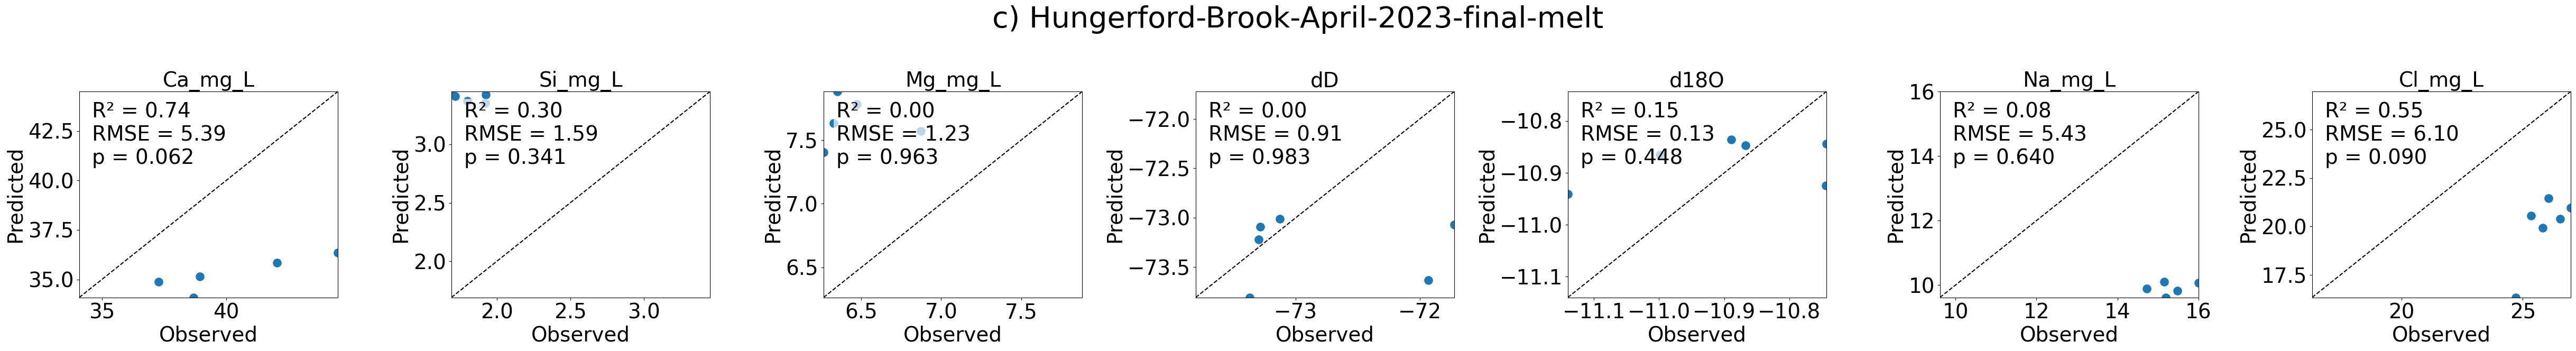

In [28]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data/GrabSample_data"

output_dir = repo_dir / "Output/EMMA-uncertainty/Tracer_regressions/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "RI23-IC-ICP-isotope-toc-joined.csv")

##########################
# Hungerford RI23 events #
##########################

# A. February ROS
# B. March thermal
# C. Final spring melt

# Hungerford April final spring melt
# Potential endmembers: 
    # RI23-5008 Groundwater (Mark's well) 03/16/2023
    # RI20-HB-DGW-Mark-1 Mark's well 06/23/2020
    # RI22-0858 03/17/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI22-0864 07/27/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI23-1035 Baseflow 03/31/2023
    # RI23-1001 # Baseflow 02/09/2023 (labeled GW)
    # RI23-5007 Soil water lysimeter dry 03/16/2023
    # RI23-1061 Snowmelt lysimeter 03/28/2023

hungerford_springmelt_fractions_df, hungerford_springmelt_scaler, hungerford_springmelt_pca, hungerford_springmelt_endmembers_df = em.run_emma_event(
    data=df,
    site="Hungerford",
    start_date="2023-03-30 00:00:00",
    end_date="2023-04-04 00:00:00",
    endmember_ids=[
                   "RI23-1001", # Baseflow 02/09/2023 (labeled GW)
                  #"RI23-1085", # Baseflow 03/31/23
                   "RI23-5008", # Groundwater (Mark's well) 03/16/2023
                   #"RI20-HB-DGW-Mark-1" # Mark's well 2020
                   #"RI22-0858", # Mark's well 03/17/2022
                   #"RI22-0864", # Mark's well 07/27/2022
                   "RI23-5013", # Soil water lysimeter wet 04/12/23
                   "RI23-5017", # Snowmelt lysimeter 04/12/23
                   "RI23-1061" # Snowmelt lysimeter 03/28/23
                    ])

hungerford_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L', 'Cl_mg_L']

# Call the prediction function
hungerford_springmelt_predicted = em.predict_tracers_from_fractions(
    fractions_df=hungerford_springmelt_fractions_df,
    endmembers_df=hungerford_springmelt_endmembers_df,
    tracer_cols=hungerford_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "c) Hungerford-Brook-April-2023-final-melt", 
    predicted_df = hungerford_springmelt_predicted, 
    stream_df = df, 
    tracer_cols = hungerford_tracers,
    output_dir=output_dir)